In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw_data/fraud_detection_dataset_SALE.csv")
print(df.shape)
df.head(3)

(8150, 12)


,transaction_id,customer_age,annual_income,account_balance,transaction_amount,nb_transactions_30d,education_level,city,device_type,has_loan,account_age_years,is_fraud
0,TXN006576,70.0,25118.503360,469.806793,193.913213,72.0,Primary,Nice,Tablet,1,8.578674,0
1,TXN000483,72.0,106873.232288,5197.276736,NaN,47.0,Primary,Lyon,MOBILE,yes,17.192097,0
2,TXN007604,65.0,51534.139916,16080.308075,532.334612,36.0,Primary,PARIS,Mobile,False,2.663638,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8150 entries, 0 to 8149
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       8150 non-null   object 
 1   customer_age         8150 non-null   float64
 2   annual_income        7024 non-null   float64
 3   account_balance      8150 non-null   float64
 4   transaction_amount   7525 non-null   float64
 5   nb_transactions_30d  8150 non-null   float64
 6   education_level      8150 non-null   object 
 7   city                 7744 non-null   object 
 8   device_type          8150 non-null   object 
 9   has_loan             8150 non-null   object 
 10  account_age_years    7242 non-null   float64
 11  is_fraud             8048 non-null   object 
dtypes: float64(6), object(6)
memory usage: 764.2+ KB


In [4]:
df.dtypes.value_counts()

object     6
float64    6
Name: count, dtype: int64

                    valeurs sans 0
annual_income                13.82
account_age_years            11.14
transaction_amount            7.67
city                          4.98
is_fraud                      1.25


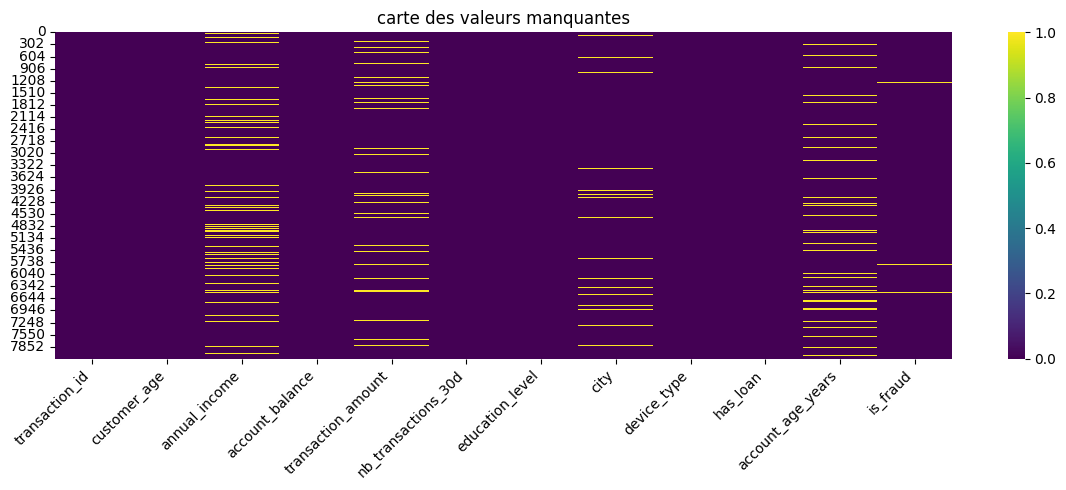

In [5]:
missing = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0].to_frame(name="valeurs sans 0").round(2)
print(missing)

plt.figure(figsize=(12,5))
sns.heatmap(df.isna(), annot=False, cmap="viridis")
plt.title("carte des valeurs manquantes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
df.duplicated().sum()

np.int64(150)

In [7]:
variables_continues = ["transaction_amount","account_balance","annual_income","customer_age","account_age_years"]
variables_discretes = ["nb_transactions_30d"]
variables_categoriel = ["device_type","education_level","city"]
variables_binaire = ["has_loan"]
variables_cible = ["is_fraud"]
variables_ignore = ["transaction_id"]


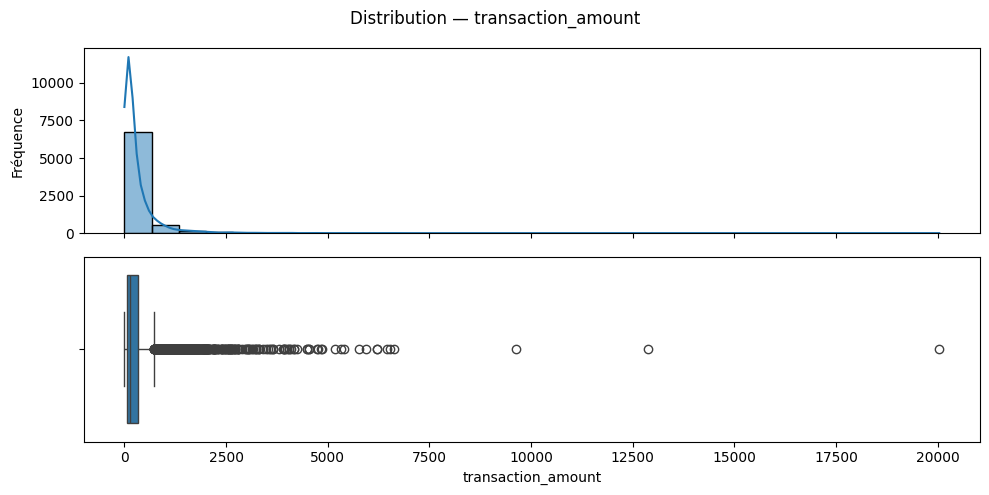

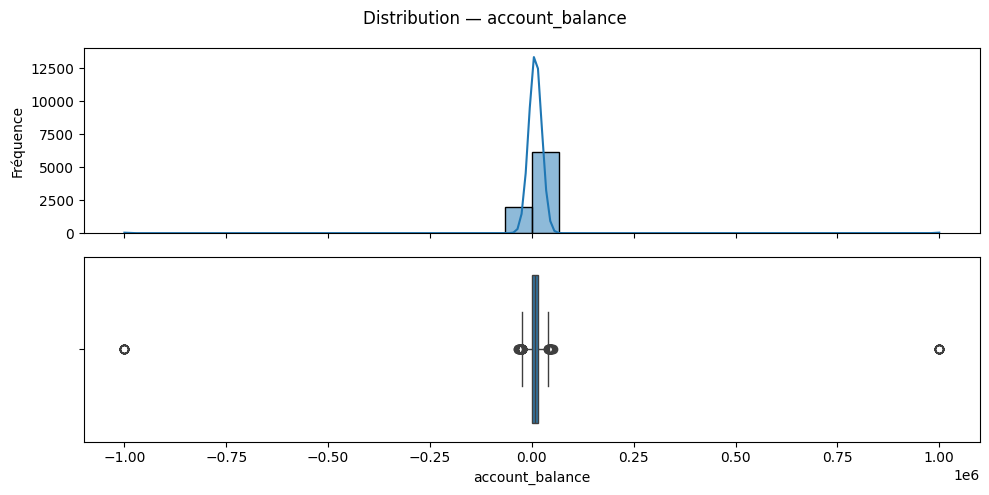

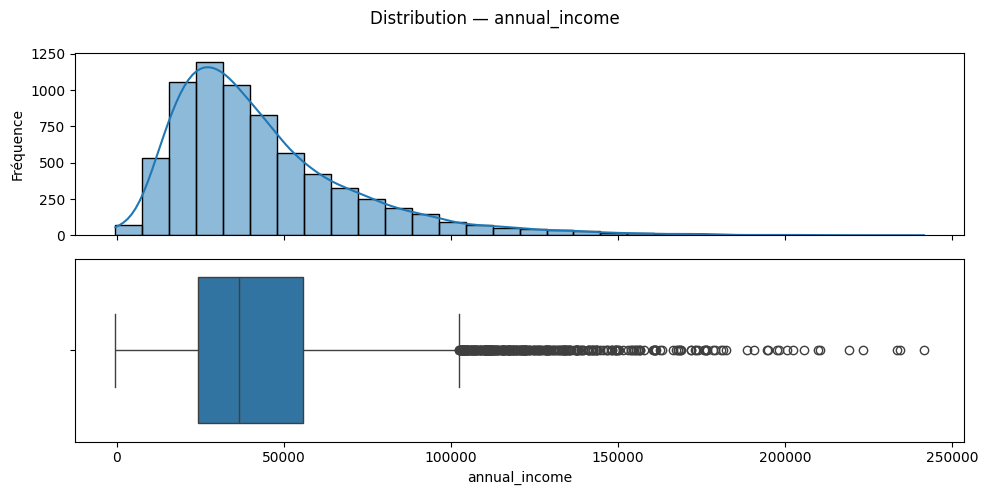

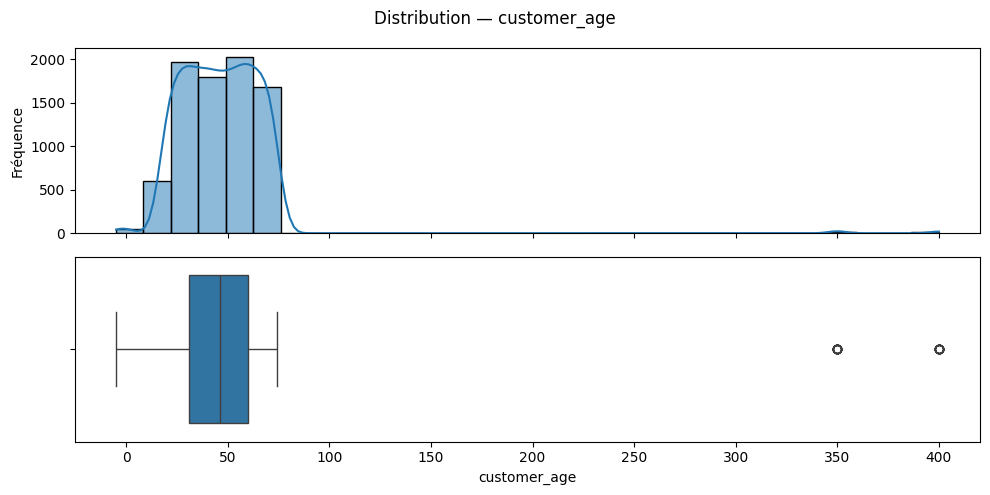

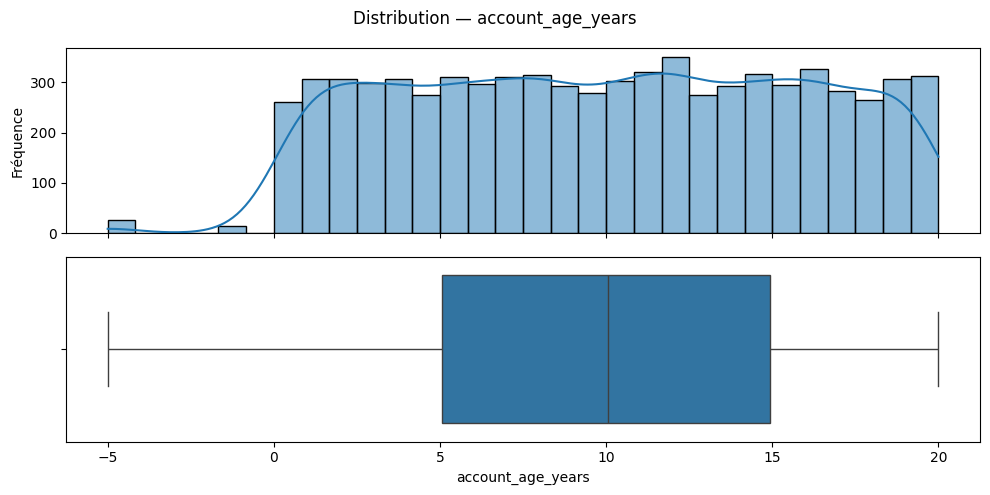

In [8]:
# ─── Variables continues : histogramme + boxplot 

for col in variables_continues:
    fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    plt.suptitle(f'Distribution — {col}', fontsize=12)
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax[0])
    sns.boxplot(x=df[col].dropna(), ax=ax[1])
    ax[0].set_ylabel('Fréquence')
    plt.tight_layout()
    plt.show()

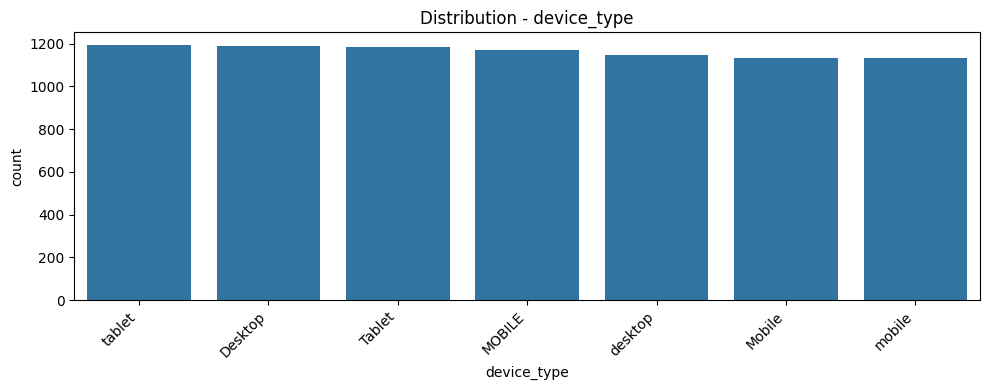

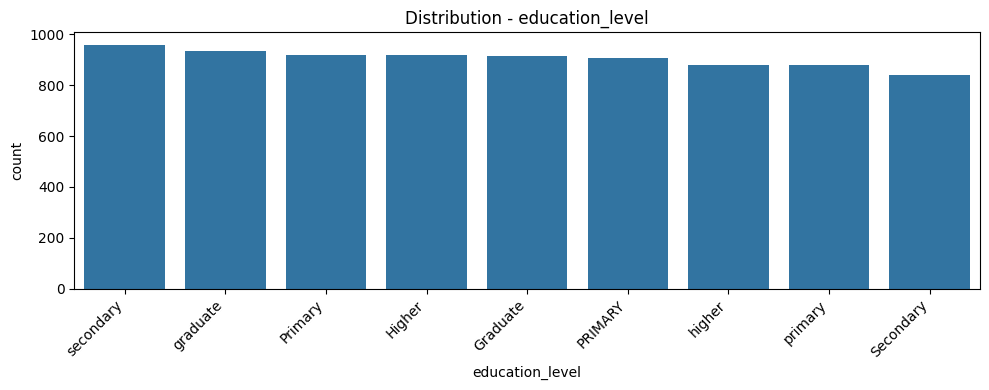

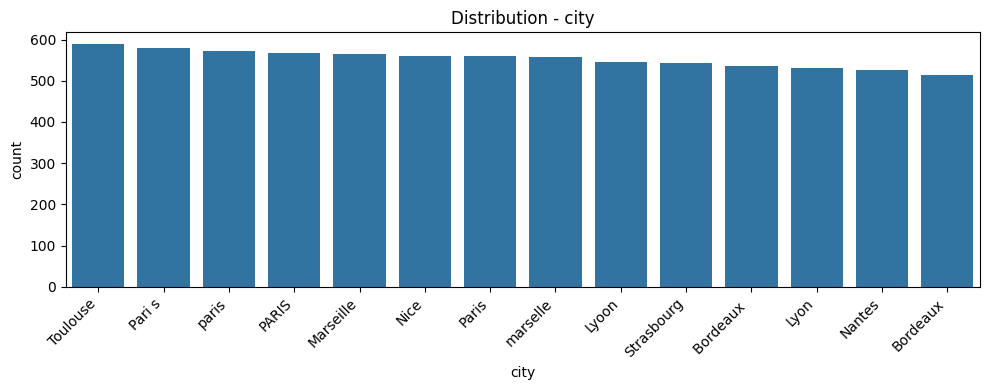

In [9]:
# ─── Variables variables_categoriel

for col in variables_categoriel:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, data=df,order=df[col].value_counts().index)
    plt.title(f"Distribution - {col}")
    plt.xticks(rotation=45,ha="right")
    plt.tight_layout()
    plt.show()

<Axes: xlabel='nb_transactions_30d', ylabel='count'>

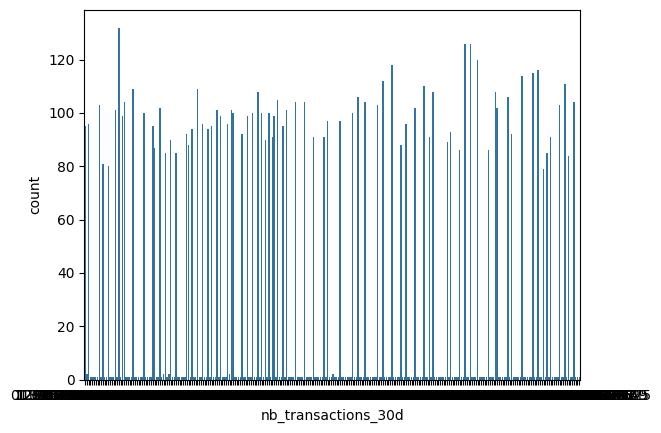

In [10]:
# variables_discretes
sns.countplot(x="nb_transactions_30d",data=df)

<Axes: xlabel='has_loan'>

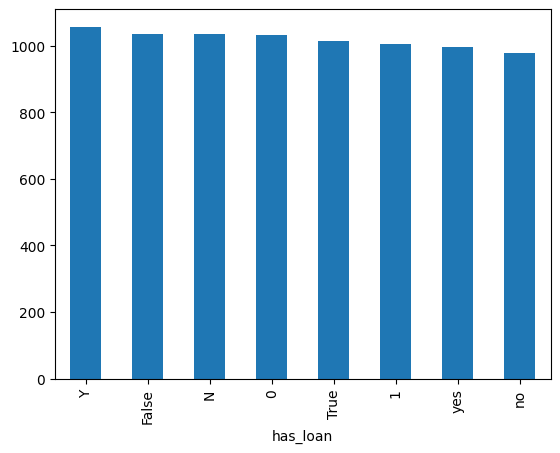

In [11]:
df["has_loan"].value_counts().plot(kind="bar")

<Axes: xlabel='is_fraud'>

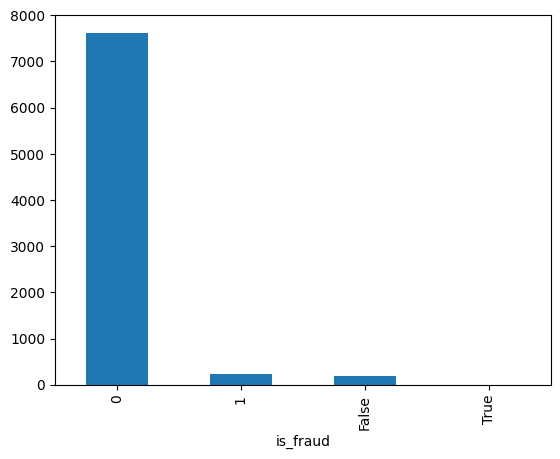

In [12]:
df["is_fraud"].value_counts().plot(kind="bar")


In [13]:
df["is_fraud"].value_counts()


is_fraud
0        7623
1         226
False     197
True        2
Name: count, dtype: int64

In [19]:
cols_numeriques = variables_continues + variables_discretes +variables_cible
df_num = df[cols_numeriques].apply(pd.to_numeric, errors="coerce")

outliers_report = []
for col in cols_numeriques:
    q1 = df_num[col].quantile(0.25)
    q3 = df_num[col].quantile(0.75)
    iqr = q3 - q1
    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr
    n_outliers = ((df_num[col] < lower) | (df_num[col]> upper)).sum()
    pct = n_outliers / df_num[col].notna().sum()*100
    outliers_report.append({
    "feature":col,
    'lower_bound': round(lower, 1),
    'upper_bound': round(upper, 1),
    'n_outliers':  n_outliers,
    'pct_outliers': round(pct, 2)
})

df_outliers = pd.DataFrame(outliers_report).sort_values("pct_outliers",ascending=False)
print(df_outliers.to_string(index=False))


            feature  lower_bound  upper_bound  n_outliers  pct_outliers
    account_balance            0      40438.7        2028         24.88
 transaction_amount            0        735.6         708          9.41
      annual_income            0     102484.0         361          5.14
           is_fraud            0          0.0         226          2.88
       customer_age            0        103.5          66          0.81
  account_age_years            0         29.7          41          0.57
nb_transactions_30d            0        120.0           0          0.00


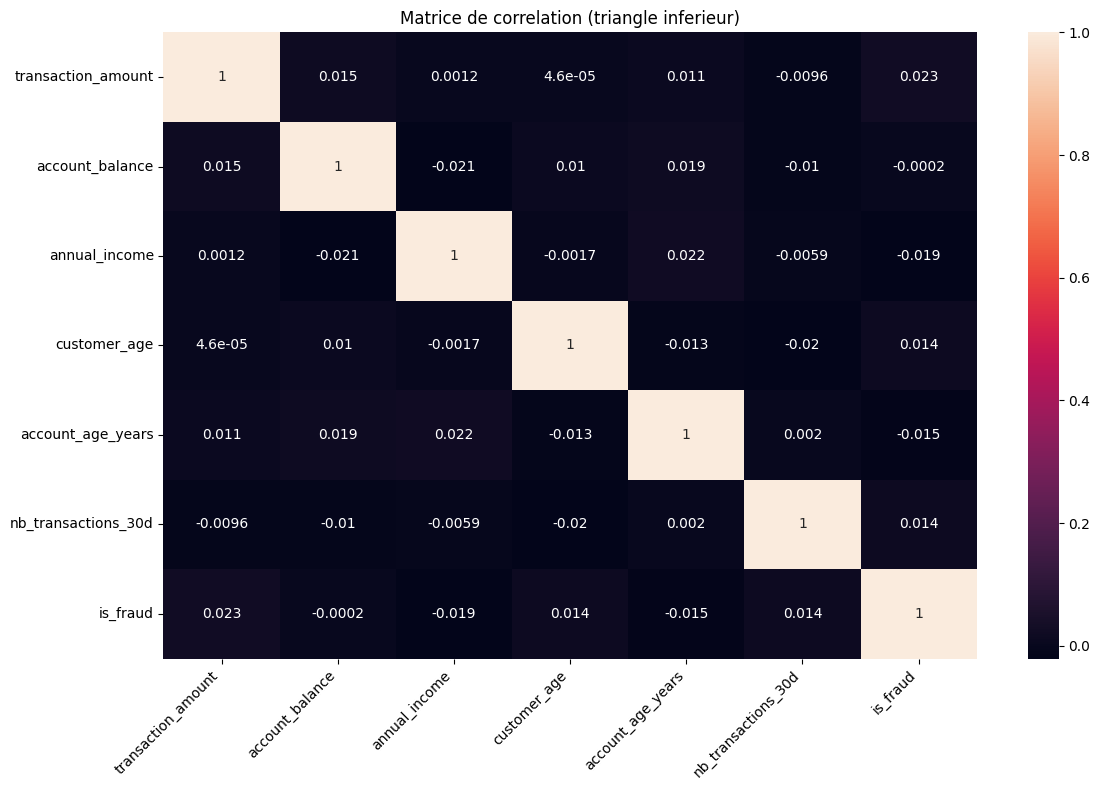

In [20]:
corr = df_num.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True)
plt.title("Matrice de correlation (triangle inferieur)")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

In [22]:

# Top corrélations avec is_fraud
print("\nTop corrélations avec is_fraud :")
print(corr['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False).round(3))


Top corrélations avec is_fraud :
transaction_amount     0.023
annual_income         -0.019
account_age_years     -0.015
customer_age           0.014
nb_transactions_30d    0.014
account_balance       -0.000
Name: is_fraud, dtype: float64
